# DP-ECG: Utility Sweep with Multi-Seed Aggregation

Loads multi-seed results from `results/baseline/seed_<S>/` and
`results/dp/<mech>/eps_<eps>_delta_<delta>/seed_<S>/` and produces:

  * Diagnostic plots with mean +- std bands (3 seeds per config).
  * Individual seed points as ghost dots so the underlying variance is
    visible, not hidden behind aggregation.
  * Sanity checks (monotonicity, baseline convergence, low-eps degradation).
  * Stability table with per-config std and coefficient of variation.

**What we want to see:**
1. **Monotonicity**: macro-F1 increases monotonically with eps (mean curve).
2. **Limits**: at large eps -> baseline F1 (~0.92). At small eps -> majority
   class collapse.
3. **Mechanism ranking**: similar curves between Laplace variants, Analytic
   Gaussian may differ at low eps.
4. **Per-class behaviour**: S (rare class) degrades first, V last.
5. **Stability**: std across seeds should be small in monotonic regions and
   may be larger near transitions (eps ~0.1-0.5).

In [1]:
import os
import sys
from pathlib import Path

# Robust path setup: find repo root regardless of where the kernel started
def _find_repo_root() -> Path:
    try:
        here = Path.cwd()
    except (FileNotFoundError, OSError):
        os.chdir(os.path.expanduser('~'))
        here = Path.cwd()
    for candidate in [here, *here.parents]:
        if (candidate / 'configs' / 'config.py').exists() and (candidate / 'src').is_dir():
            return candidate
    return here.parent if (here.parent / 'configs').exists() else here

REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))  # for _loader.py
os.chdir(REPO_ROOT)
print(f'Repo root: {REPO_ROOT}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from _loader import (
    load_utility_baseline, load_utility_sweep,
    aggregate_over_seeds,
)

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 14, 'axes.labelsize': 13,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
    'savefig.bbox': 'tight', 'figure.constrained_layout.use': False,
})

RESULTS = REPO_ROOT / 'results'
FIGURES = REPO_ROOT / 'results' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

MECH_LABELS = {
    'laplace': 'Laplace',
    'laplace_bounded': 'Bounded Laplace',
    'gaussian_analytic': 'Analytic Gaussian',
}
MECH_ORDER = ['laplace', 'laplace_bounded', 'gaussian_analytic']
CLASS_COLORS = {'N': '#1f77b4', 'S': '#d62728', 'V': '#2ca02c'}

Repo root: <repo>


## Load data

In [2]:
baseline_df = load_utility_baseline(RESULTS)
sweep_df = load_utility_sweep(RESULTS)

print(f'Baseline rows: {len(baseline_df)}')
print(f'Sweep rows:    {len(sweep_df)}')

if not baseline_df.empty:
    print()
    print('Baseline summary (across seeds):')
    print(baseline_df[['macro_f1', 'f1_N', 'f1_S', 'f1_V']].agg(['mean', 'std', 'min', 'max']).round(4))
    baseline_macro_mean = baseline_df['macro_f1'].mean()
    baseline_macro_std = baseline_df['macro_f1'].std()
    baseline_per_class = {
        'N': baseline_df['f1_N'].mean(),
        'S': baseline_df['f1_S'].mean(),
        'V': baseline_df['f1_V'].mean(),
    }
else:
    baseline_macro_mean = np.nan
    baseline_macro_std = np.nan
    baseline_per_class = {}

Baseline rows: 3
Sweep rows:    162

Baseline summary (across seeds):
      macro_f1    f1_N    f1_S    f1_V
mean    0.9501  0.9938  0.8640  0.9925
std     0.0247  0.0032  0.0691  0.0035
min     0.9241  0.9904  0.7897  0.9892
max     0.9732  0.9969  0.9265  0.9963


In [3]:
value_cols = ['macro_f1', 'f1_N', 'f1_S', 'f1_V']
agg = aggregate_over_seeds(sweep_df, ['mechanism', 'eps', 'delta'], value_cols)
print('Aggregated rows:', len(agg))
agg.head(8).round(3)

Aggregated rows: 54


macro_f1                              f1_N  \
                                    mean    std    min    max count   mean   
mechanism         eps   delta                                                
gaussian_analytic 0.050 0.00001    0.260  0.134  0.107  0.350     3  0.025   
                  0.100 0.00001    0.513  0.056  0.479  0.578     3  0.476   
                  0.150 0.00001    0.606  0.025  0.577  0.621     3  0.723   
                  0.175 0.00001    0.631  0.005  0.625  0.635     3  0.773   
                  0.200 0.00001    0.664  0.013  0.655  0.678     3  0.845   
                  0.225 0.00001    0.686  0.013  0.672  0.695     3  0.880   
                  0.250 0.00001    0.719  0.015  0.704  0.735     3  0.915   
                  0.300 0.00001    0.705  0.069  0.624  0.745     3  0.885   

                                                             f1_S         \
                                   std    min    max count   mean    std   
mechanism         eps   delta                                              
gaussian_analytic 0.050 0.00001  0.031  0.006  0.061     3  0.053  0.031   
                  0.100 0.00001  0.134  0.358  0.622     3  0.105  0.014   
                  0.150 0.00001  0.021  0.701  0.743     3  0.155  0.001   
                  0.175 0.00001  0.026  0.743  0.790     3  0.178  0.013   
                  0.200 0.00001  0.034  0.806  0.866     3  0.214  0.041   
                  0.225 0.00001  0.021  0.859  0.900     3  0.251  0.017   
                  0.250 0.00001  0.024  0.890  0.938     3  0.292  0.022   
                  0.300 0.00001  0.070  0.804  0.935     3  0.308  0.134   

                                                      f1_V                \
                                   min    max count   mean    std    min   
mechanism         eps   delta                                              
gaussian_analytic 0.050 0.00001  0.018  0.073     3  0.702  0.400  0.242   
                  0.100 0.00001  0.091  0.120     3  0.959  0.052  0.899   
                  0.150 0.00001  0.154  0.156     3  0.938  0.058  0.874   
                  0.175 0.00001  0.163  0.189     3  0.942  0.050  0.904   
                  0.200 0.00001  0.186  0.260     3  0.934  0.035  0.909   
                  0.225 0.00001  0.236  0.270     3  0.927  0.018  0.910   
                  0.250 0.00001  0.276  0.318     3  0.950  0.018  0.939   
                  0.300 0.00001  0.163  0.426     3  0.920  0.058  0.871   

                                              
                                   max count  
mechanism         eps   delta                 
gaussian_analytic 0.050 0.00001  0.969     3  
                  0.100 0.00001  0.991     3  
                  0.150 0.00001  0.984     3  
                  0.175 0.00001  0.998     3  
                  0.200 0.00001  0.974     3  
                  0.225 0.00001  0.947     3  
                  0.250 0.00001  0.971     3  
                  0.300 0.00001  0.985     3

## Figure 1: Macro-F1 vs epsilon (mean +- std, ghost dots per seed)

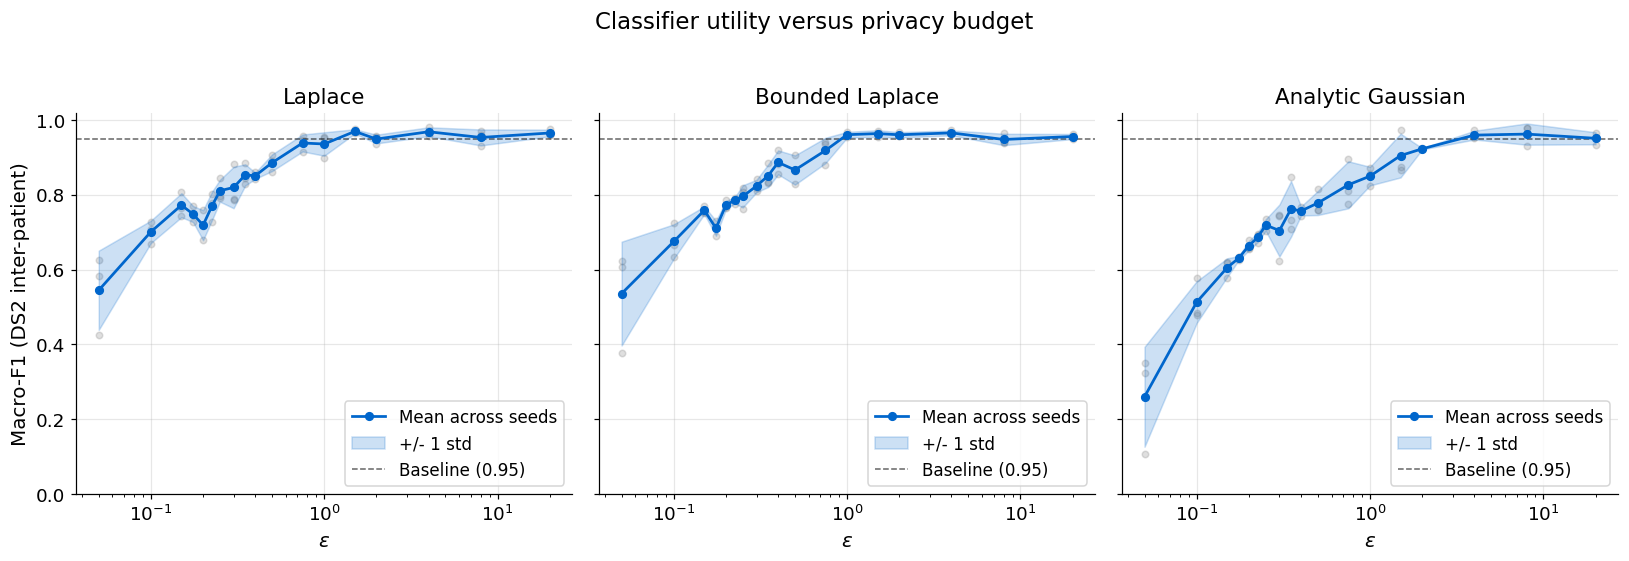

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.0), sharey=True)

for ax, mech in zip(axes, MECH_ORDER):
    sub_raw = sweep_df[sweep_df['mechanism'] == mech].sort_values('eps')
    if sub_raw.empty:
        ax.set_title(f'{MECH_LABELS[mech]} (no data)')
        continue

    grp = sub_raw.groupby('eps')['macro_f1'].agg(['mean', 'std']).reset_index()

    ax.scatter(sub_raw['eps'], sub_raw['macro_f1'],
               s=18, alpha=0.25, color='gray', zorder=1)

    ax.plot(grp['eps'], grp['mean'], 'o-', color='#0066CC',
            linewidth=1.8, markersize=5, zorder=3,
            label='Mean across seeds')
    ax.fill_between(grp['eps'], grp['mean'] - grp['std'], grp['mean'] + grp['std'],
                     alpha=0.20, color='#0066CC', zorder=2,
                     label='+/- 1 std')

    if not np.isnan(baseline_macro_mean):
        ax.axhline(baseline_macro_mean, color='black', linestyle='--',
                   linewidth=1, alpha=0.6,
                   label=f'Baseline ({baseline_macro_mean:.2f})')

    ax.set_xscale('log')
    ax.set_xlabel(r'$\varepsilon$')
    ax.set_title(MECH_LABELS[mech])
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=11, loc='lower right')

axes[0].set_ylabel('Macro-F1 (DS2 inter-patient)')
fig.suptitle('Classifier utility versus privacy budget', y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES / 'utility_vs_epsilon.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'utility_vs_epsilon.png', bbox_inches='tight')
plt.show()

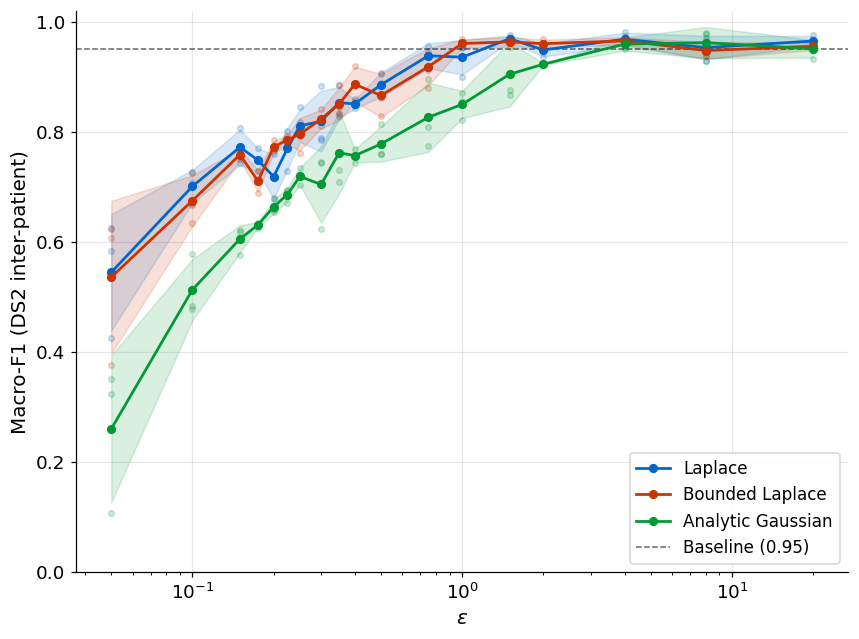

In [5]:
COLORS = ['#0066CC', '#CC3300', '#009933']

fig, ax = plt.subplots(figsize=(8, 6))

for mech, color in zip(MECH_ORDER, COLORS):
    sub_raw = sweep_df[sweep_df['mechanism'] == mech].sort_values('eps')
    if sub_raw.empty:
        continue

    grp = sub_raw.groupby('eps')['macro_f1'].agg(['mean', 'std']).reset_index()

    ax.scatter(sub_raw['eps'], sub_raw['macro_f1'],
               s=14, alpha=0.20, color=color, zorder=1)

    ax.plot(grp['eps'], grp['mean'], 'o-', color=color,
            linewidth=1.8, markersize=5, zorder=3,
            label=MECH_LABELS[mech])
    ax.fill_between(grp['eps'], grp['mean'] - grp['std'], grp['mean'] + grp['std'],
                     alpha=0.15, color=color, zorder=2)

if not np.isnan(baseline_macro_mean):
    ax.axhline(baseline_macro_mean, color='black', linestyle='--',
               linewidth=1, alpha=0.6,
               label=f'Baseline ({baseline_macro_mean:.2f})')

ax.set_xscale('log')
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel('Macro-F1 (DS2 inter-patient)')
ax.set_ylim(0, 1.02)
#ax.set_title('Classifier utility versus privacy budget', fontsize=15)
ax.legend(fontsize=11, loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES / 'utility_vs_epsilon_combined.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'utility_vs_epsilon_combined.png', bbox_inches='tight')
plt.show()

## Figure 2: Per-class F1 breakdown

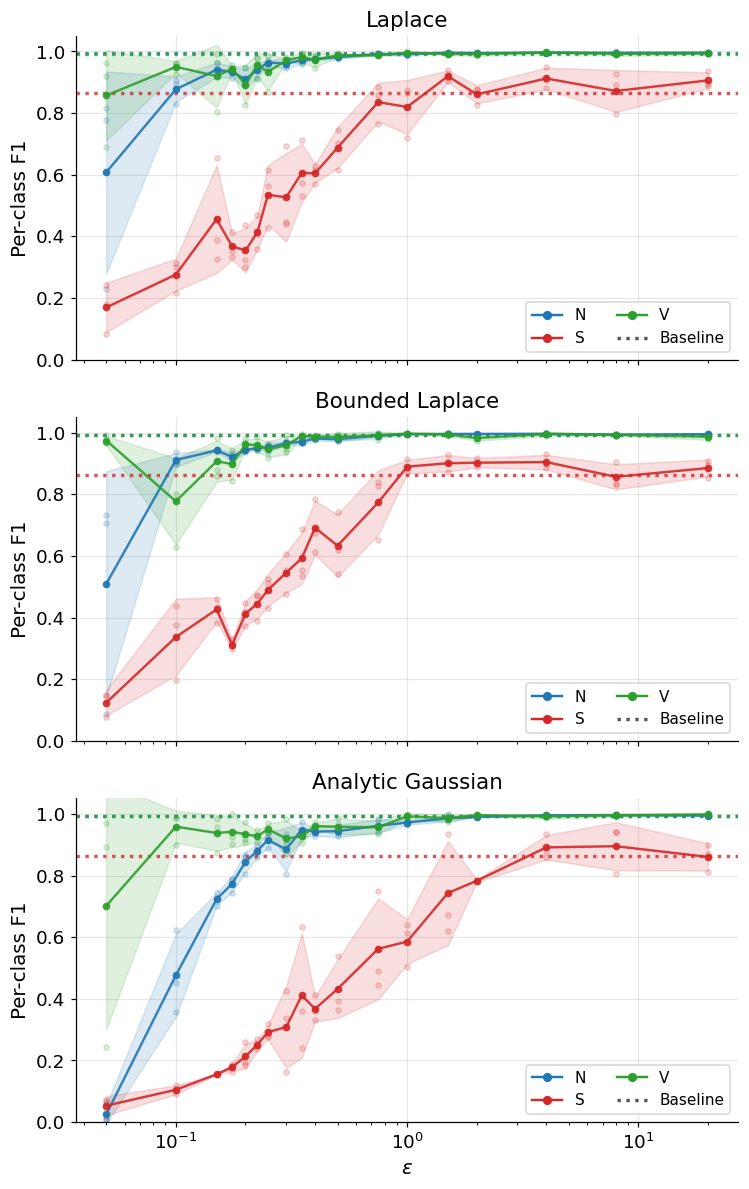

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 1, figsize=(7.0, 11.0), sharex=True, sharey=True)

for ax, mech in zip(axes, MECH_ORDER):
    sub_raw = sweep_df[sweep_df['mechanism'] == mech].sort_values('eps')
    if sub_raw.empty:
        ax.set_title(f'{MECH_LABELS[mech]} (no data)')
        continue

    for cls, col in zip(['N', 'S', 'V'], ['f1_N', 'f1_S', 'f1_V']):
        grp = sub_raw.groupby('eps')[col].agg(['mean', 'std']).reset_index()
        color = CLASS_COLORS[cls]
        ax.scatter(sub_raw['eps'], sub_raw[col],
                   s=12, alpha=0.18, color=color, zorder=1)
        ax.plot(grp['eps'], grp['mean'], 'o-', color=color,
                linewidth=1.6, markersize=4, label=cls, alpha=0.9, zorder=3)
        ax.fill_between(grp['eps'], grp['mean'] - grp['std'], grp['mean'] + grp['std'],
                         alpha=0.15, color=color, zorder=2)
        if baseline_per_class:
            ax.axhline(baseline_per_class.get(cls, np.nan),
                       color=color, linestyle=':', linewidth=2.2, alpha=0.8, zorder=2.5)

    ax.set_xscale('log')
    ax.set_title(MECH_LABELS[mech])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Per-class F1')

    # class handles + one neutral handle explaining the dotted baseline
    class_h = [Line2D([0], [0], color=CLASS_COLORS[c], marker='o', linewidth=1.6,
                      markersize=5, label=c) for c in ['N', 'S', 'V']]
    base_h = [Line2D([0], [0], color='#555', linestyle=':', linewidth=2.2,
                     label='Baseline')]
    ax.legend(handles=class_h + base_h, fontsize=10, loc='lower right', ncol=2)

axes[-1].set_xlabel(r'$\varepsilon$')
#fig.suptitle('Per-class utility versus privacy budget (dotted: Baseline)', y=1.005, fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES / 'per_class_vs_epsilon.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'per_class_vs_epsilon.png', bbox_inches='tight')
plt.show()

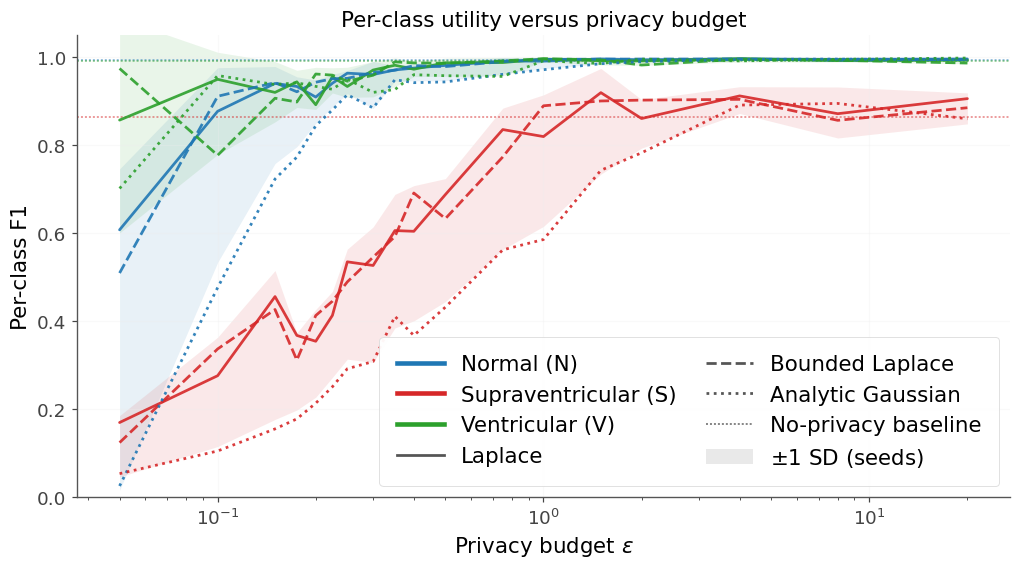

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# --- publication-quality style ---
mpl.rcParams.update({
    'font.size': 14,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#555555', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.color': '#ededed', 'grid.linewidth': 0.8,
    'xtick.color': '#444444', 'ytick.color': '#444444',
    'axes.titlesize': 14, 'axes.labelsize': 14,
})

# mechanism -> line style (color is reserved for the class); built dynamically
_ls = ['-', '--', ':']
MECH_LS = {m: _ls[i % 3] for i, m in enumerate(MECH_ORDER)}

# full class names for the legend (adjust if your label scheme differs)
CLASS_FULL = {'N': 'Normal (N)', 'S': 'Supraventricular (S)', 'V': 'Ventricular (V)'}

fig, ax = plt.subplots(figsize=(9.5, 5.4))

# --- faint per-class variability band (pooled across mechanisms + seeds) ---
for cls, col in zip(['N', 'S', 'V'], ['f1_N', 'f1_S', 'f1_V']):
    g = sweep_df.groupby('eps')[col].agg(['mean', 'std']).reset_index()
    ax.fill_between(g['eps'], g['mean'] - g['std'], g['mean'] + g['std'],
                    color=CLASS_COLORS[cls], alpha=0.10, linewidth=0, zorder=1)

# --- mean curves: color = class, line style = mechanism (true means, no smoothing) ---
for mech in MECH_ORDER:
    sub = sweep_df[sweep_df['mechanism'] == mech].sort_values('eps')
    if sub.empty:
        continue
    for cls, col in zip(['N', 'S', 'V'], ['f1_N', 'f1_S', 'f1_V']):
        grp = sub.groupby('eps')[col].mean().reset_index()
        ax.plot(grp['eps'], grp[col], linestyle=MECH_LS[mech],
                color=CLASS_COLORS[cls], linewidth=1.8, alpha=0.9,
                solid_capstyle='round', zorder=3)

# --- no-privacy baselines, color-matched and faint ---
if baseline_per_class:
    for cls in ['N', 'S', 'V']:
        ax.axhline(baseline_per_class.get(cls, np.nan), color=CLASS_COLORS[cls],
                   linestyle=(0, (1, 1)), linewidth=1.3, alpha=0.45, zorder=2)

ax.set_xscale('log')
ax.set_ylim(0, 1.05)
ax.set_xlabel(r'Privacy budget $\varepsilon$')
ax.set_ylabel('Per-class F1')
ax.set_title('Per-class utility versus privacy budget')

# --- two-block legend: classes (color) + mechanisms (line style) + extras ---
class_h = [Line2D([0], [0], color=CLASS_COLORS[c], linewidth=3, label=CLASS_FULL[c])
           for c in ['N', 'S', 'V']]
mech_h = [Line2D([0], [0], color='#555', linestyle=MECH_LS[m], linewidth=1.8,
                 label=MECH_LABELS[m]) for m in MECH_ORDER]
extra_h = [Line2D([0], [0], color='#888', linestyle=(0, (1, 1)), linewidth=1.3,
                  label='No-privacy baseline'),
           Patch(facecolor='#888', alpha=0.18, edgecolor='none', label=r'$\pm$1 SD (seeds)')]

leg = ax.legend(handles=class_h + mech_h + extra_h, fontsize=14, loc='lower right',
                ncol=2, framealpha=0.96, edgecolor='#dddddd',
                borderpad=0.8, labelspacing=0.5, columnspacing=1.4, handlelength=2.2)
leg.get_frame().set_linewidth(0.6)

fig.tight_layout()
fig.savefig(FIGURES / 'per_class_vs_epsilon_combined.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'per_class_vs_epsilon_combined.png', dpi=200, bbox_inches='tight')
plt.show()

## Figure 3: Heatmap (mean macro-F1 across seeds)

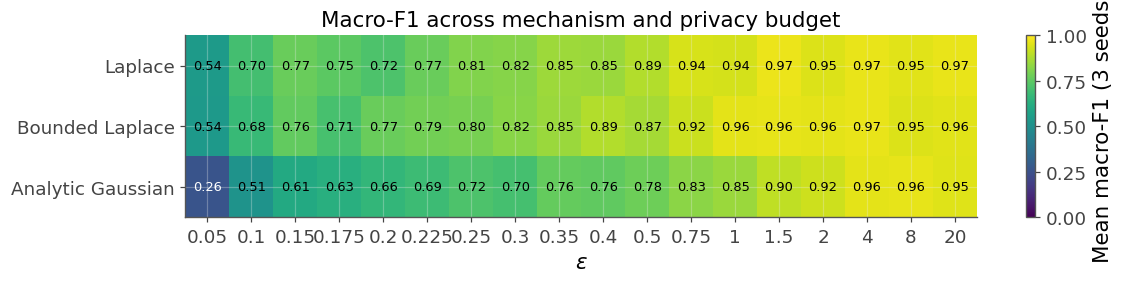

In [8]:
heat_data = (
    sweep_df.groupby(['mechanism', 'eps'])['macro_f1']
    .mean().reset_index()
)
heat = heat_data.pivot(index='mechanism', columns='eps', values='macro_f1')
heat = heat.reindex([m for m in MECH_ORDER if m in heat.index])
heat = heat.sort_index(axis=1)

fig, ax = plt.subplots(figsize=(11, 2.8))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([MECH_LABELS.get(m, m) for m in heat.index])
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f'{x:g}' for x in heat.columns])
ax.set_xlabel(r'$\varepsilon$')
fig.colorbar(im, ax=ax, label='Mean macro-F1 (3 seeds)')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not np.isnan(v):
            color = 'white' if v < 0.5 else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5, color=color)
ax.set_title('Macro-F1 across mechanism and privacy budget')
fig.tight_layout()
fig.savefig(FIGURES / 'heatmap_macro_f1.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'heatmap_macro_f1.png', bbox_inches='tight')
plt.show()

## Stability table: std and CV per config

If std is large for a particular config, that config is unstable across
seeds and we should be cautious about interpreting it.

In [9]:
stab = (
    sweep_df.groupby(['mechanism', 'eps'])['macro_f1']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)
stab['cv'] = stab['std'] / stab['mean'].abs()
stab['range'] = stab['max'] - stab['min']
print('Top 10 most unstable (highest CV):')
print(stab.sort_values('cv', ascending=False).head(10).round(3).to_string(index=False))
print()
print('Per-mechanism summary:')
print(stab.groupby('mechanism')[['std', 'cv', 'range']].agg(['mean', 'max']).round(3))

Top 10 most unstable (highest CV):
        mechanism  eps  mean   std   min   max  count    cv  range
gaussian_analytic 0.05 0.260 0.134 0.107 0.350      3 0.513  0.244
  laplace_bounded 0.05 0.536 0.139 0.376 0.624      3 0.259  0.248
          laplace 0.05 0.545 0.106 0.425 0.626      3 0.194  0.201
gaussian_analytic 0.10 0.513 0.056 0.479 0.578      3 0.109  0.099
gaussian_analytic 0.30 0.705 0.069 0.624 0.745      3 0.099  0.121
gaussian_analytic 0.35 0.762 0.074 0.708 0.847      3 0.098  0.139
gaussian_analytic 0.75 0.827 0.063 0.775 0.896      3 0.076  0.122
  laplace_bounded 0.10 0.675 0.046 0.634 0.725      3 0.068  0.091
          laplace 0.30 0.820 0.055 0.786 0.884      3 0.068  0.098
gaussian_analytic 1.50 0.905 0.058 0.867 0.972      3 0.065  0.105

Per-mechanism summary:
                     std            cv         range       
                    mean    max   mean    max   mean    max
mechanism                                                  
gaussian_analytic  0.036

## Automated sanity checks

In [10]:
checks = []
agg_simple = sweep_df.groupby(['mechanism', 'eps'])['macro_f1'].mean().reset_index()
for mech in agg_simple['mechanism'].unique():
    sub = agg_simple[agg_simple['mechanism'] == mech].sort_values('eps')
    if len(sub) < 2:
        continue
    f1_arr = sub['macro_f1'].values
    violations = int(np.sum(np.diff(f1_arr) < -0.05))
    high_eps_f1 = float(f1_arr[-1])
    low_eps_f1 = float(f1_arr[0])
    gap = baseline_macro_mean - high_eps_f1 if not np.isnan(baseline_macro_mean) else np.nan
    checks.append({
        'mechanism': mech,
        'n_eps': len(sub),
        'low_eps_F1': low_eps_f1,
        'high_eps_F1': high_eps_f1,
        'gap_to_baseline': gap,
        'large_drops (>0.05)': violations,
    })
check_df = pd.DataFrame(checks)
print(check_df.round(3).to_string(index=False))

issues = []
for _, row in check_df.iterrows():
    label = row['mechanism']
    if row['large_drops (>0.05)'] > 2:
        issues.append(f'  {label}: {int(row["large_drops (>0.05)"])} non-monotonic drops')
    if not np.isnan(row['gap_to_baseline']) and row['gap_to_baseline'] > 0.15:
        issues.append(f'  {label}: high-eps F1 = {row["high_eps_F1"]:.3f}, gap to baseline {row["gap_to_baseline"]:.3f}')
    if row['low_eps_F1'] > 0.7:
        issues.append(f'  {label}: low-eps F1 = {row["low_eps_F1"]:.3f} unusually high')

print()
print('Issues found:' if issues else 'All sanity checks pass.')
for s in issues:
    print(s)

        mechanism  n_eps  low_eps_F1  high_eps_F1  gap_to_baseline  large_drops (>0.05)
gaussian_analytic     18       0.260        0.951           -0.001                    0
          laplace     18       0.545        0.965           -0.015                    0
  laplace_bounded     18       0.536        0.956           -0.006                    0

All sanity checks pass.


## Export

In [11]:
agg_export = (
    sweep_df.groupby(['mechanism', 'eps'])
    [['macro_f1', 'f1_N', 'f1_S', 'f1_V']]
    .agg(['mean', 'std'])
    .reset_index()
)
agg_export.columns = ['_'.join(c).strip('_') for c in agg_export.columns]
csv_path = RESULTS / 'dp_sweep_summary.csv'
agg_export.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')
agg_export.head().round(3)

Saved: <repo>/results/dp_sweep_summary.csv


,mechanism,eps,macro_f1_mean,macro_f1_std,f1_N_mean,f1_N_std,f1_S_mean,f1_S_std,f1_V_mean,f1_V_std
0,gaussian_analytic,0.050,0.260,0.134,0.025,0.031,0.053,0.031,0.702,0.400
1,gaussian_analytic,0.100,0.513,0.056,0.476,0.134,0.105,0.014,0.959,0.052
2,gaussian_analytic,0.150,0.606,0.025,0.723,0.021,0.155,0.001,0.938,0.058
3,gaussian_analytic,0.175,0.631,0.005,0.773,0.026,0.178,0.013,0.942,0.050
4,gaussian_analytic,0.200,0.664,0.013,0.845,0.034,0.214,0.041,0.934,0.035
